In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Create the data/raw directory if it doesn't exist
os.makedirs('../data/raw', exist_ok=True)

print("Fetching dataset from OpenML...")
# Fetching the authoritative Ames Housing dataset
housing = fetch_openml(name="house_prices", as_frame=True, parser="pandas")
df = housing.frame

# Save the raw file so you don't have to download it again
df.to_csv('../data/raw/ames_housing_raw.csv', index=False)
print(f"Dataset loaded successfully! Shape: {df.shape}")


Fetching dataset from OpenML...
Dataset loaded successfully! Shape: (1460, 81)


In [2]:
# Look at the target variable distribution and types
print(df.info())

# Check for features with the most missing values
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
missing_df = pd.concat([missing_data, missing_percentage], axis=1, keys=['Total Missing', 'Percent'])

print("\nTop 10 features with missing values:")
print(missing_df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

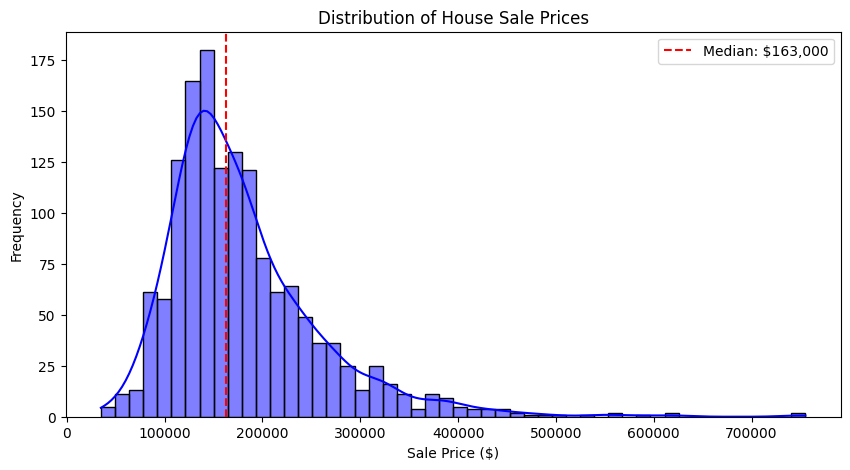

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, bins=50, color='blue')
plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.axvline(df['SalePrice'].median(), color='red', linestyle='--', label=f"Median: ${df['SalePrice'].median():,.0f}")
plt.legend()
plt.show()


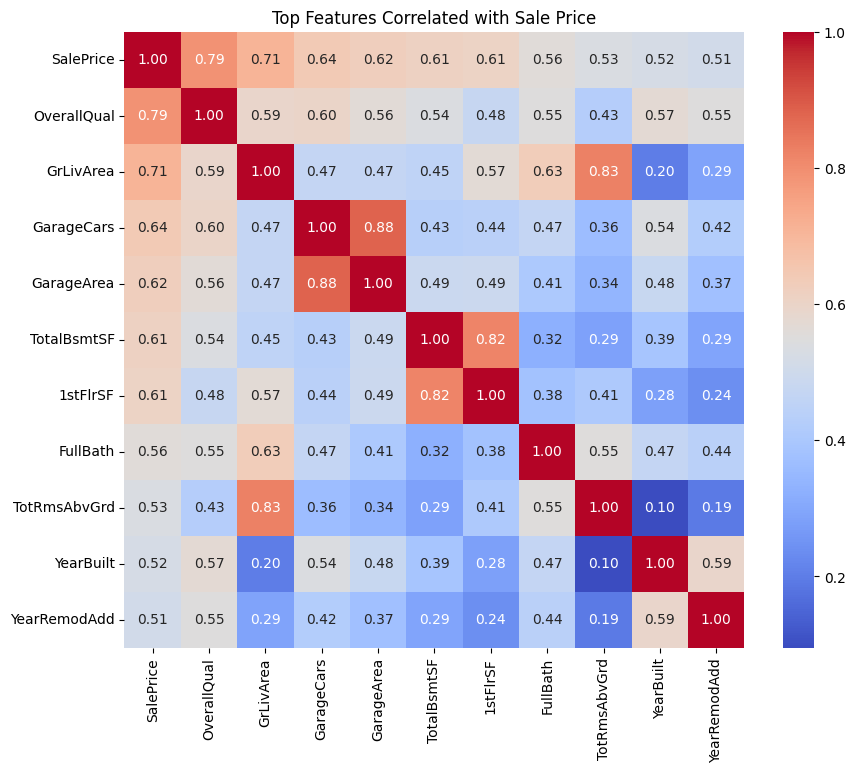

In [4]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Top 10 features most correlated with SalePrice
top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top Features Correlated with Sale Price')
plt.show()
